# Object-Oriented Programming: A to Z with Battery Modelling
### Based on *"Battery Modelling: Mathematics with Physical Meaning"*

---

Every concept in this course maps directly to a real piece of battery physics from the lecture notes.
By the end you will have built a complete, working **Battery Management System (BMS)** using pure OOP.

| Chapter | OOP Concept | Battery Physics |
|---------|-------------|-----------------|
| 1 | Classes & Objects | What a battery cell *is* |
| 2 | `__init__` & Attributes | Cell parameters (capacity, chemistry) |
| 3 | Instance Methods | OCV look-up, Coulomb counting |
| 4 | Encapsulation & Properties | SoC validation, safe access |
| 5 | Class & Static Methods | Factory constructors, Arrhenius law |
| 6 | Dunder Methods | Series/parallel string representation |
| 7 | Inheritance | NMC vs LFP chemistry sub-classes |
| 8 | Polymorphism | Mixed battery packs |
| 9 | Abstract Base Classes | Enforcing the cell interface |
| 10 | Composition | RC branches → ECM → BatteryPack |
| 11 | Dataclasses & Type Hints | Thermal model, Fade model |
| 12 | Full Simulation | Complete BMS loop + EKF + plots |


---
## Chapter 1 — Classes & Objects

### The Big Idea
A **class** is a blueprint. An **object** (instance) is a real thing built from that blueprint.

From the lecture notes:
> *"A battery consists of two electrodes (anode and cathode) immersed in an electrolyte."*

That description IS a class definition — it tells us what every battery has in common.  
An actual Samsung 21700 cell sitting on your desk is one **instance** of that class.

```
Class BatteryCell  ←  blueprint (the idea of a battery)
    └── cell_A      ←  object / instance (a real cell)
    └── cell_B      ←  another object, same blueprint
```

### Syntax
```python
class ClassName:
    pass
```
`class` keyword + name (PascalCase by convention) + colon. That's it.

In [1]:
# ============================================================
# CHAPTER 1 — Your very first class
# ============================================================

class BatteryCell:
    """The simplest possible battery cell class — just a name."""
    pass   # 'pass' means: nothing inside yet, but the class exists


# --- Creating objects (instances) ---
cell_a = BatteryCell()   # instantiate
cell_b = BatteryCell()   # a different object in memory

print(type(cell_a))          # <class '__main__.BatteryCell'>
print(isinstance(cell_a, BatteryCell))   # True

# Each object is independent in memory
print(cell_a is cell_b)      # False  ← different objects
print(id(cell_a), id(cell_b))  # different memory addresses

# You can bolt attributes onto any object at runtime (not recommended — see Ch.2)
cell_a.chemistry = "NMC"
cell_b.chemistry = "LFP"
print(cell_a.chemistry, cell_b.chemistry)  # NMC  LFP

<class '__main__.BatteryCell'>
True
False
1978272934240 1978272934096
NMC LFP


---
## Chapter 2 — `__init__` : Constructing Objects Properly

### The Problem with Chapter 1
Bolting on attributes after creation is fragile. Every cell might end up with different attributes.  
The fix: `__init__` — the **initialiser** method, called automatically when you do `BatteryCell(...)`.

### Battery Physics: Cell Parameters
From the notes, a cell needs (at minimum):
- **Nominal capacity** $Q_{nom}$ [Ah] — how much charge it can hold
- **Chemistry** — determines the OCV curve shape
- **State of charge** $z \in [0,1]$ — starts at some initial value

### Instance vs Class Attributes
| Type | Defined where | Shared? |
|------|--------------|---------|
| **Instance** attribute | inside `__init__`, via `self.x = ...` | No — each object has its own copy |
| **Class** attribute | directly in class body | Yes — shared by ALL instances |

`self` is just the name (by convention) for *"the current instance being created/used"*.

In [2]:
# ============================================================
# CHAPTER 2 — __init__, instance attributes, class attributes
# ============================================================
import numpy as np

class BatteryCell:
    # --- Class attribute: same for every instance ---
    FARADAY = 96485          # C mol⁻¹  (from the lecture notes)
    GAS_CONSTANT = 8.314     # J mol⁻¹ K⁻¹

    # --- __init__: called once per object at creation time ---
    def __init__(self, capacity_ah: float, chemistry: str,
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        """
        Parameters
        ----------
        capacity_ah   : Qnom in Ah  (e.g. 50 Ah)
        chemistry     : 'NMC' | 'LFP' | 'LTO'
        soc_init      : z₀ ∈ [0, 1]  (default: fully charged)
        temperature_k : T in Kelvin  (default: 25 °C = 298.15 K)
        """
        # Instance attributes — unique to each object
        self.capacity_ah    = capacity_ah          # Qnom [Ah]
        self.capacity_as    = capacity_ah * 3600   # Qnom [As]  (= Ah × 3600)
        self.chemistry      = chemistry
        self.soc            = soc_init             # z, mutable state
        self.temperature_k  = temperature_k        # T [K]
        self.cycle_count    = 0                    # N (full equivalent cycles)

    # A tiny helper we'll expand in Ch.3
    def summary(self):
        print(f"[{self.chemistry}]  Qnom={self.capacity_ah} Ah  "
              f"SoC={self.soc:.1%}  T={self.temperature_k-273.15:.1f}°C")


# --- Demonstration ---
nmc = BatteryCell(capacity_ah=50, chemistry="NMC")
lfp = BatteryCell(capacity_ah=100, chemistry="LFP", soc_init=0.8, temperature_k=273.15)

nmc.summary()   # [NMC]  Qnom=50 Ah  SoC=100.0%  T=25.0°C
lfp.summary()   # [LFP]  Qnom=100 Ah  SoC=80.0%  T=0.0°C

# Class attribute is the same for both
print(f"\nFaraday constant): {BatteryCell.FARADAY} C mol⁻¹")  # 96485 C mol⁻¹ ----- ----

[NMC]  Qnom=50 Ah  SoC=100.0%  T=25.0°C
[LFP]  Qnom=100 Ah  SoC=80.0%  T=0.0°C

Faraday constant): 96485 C mol⁻¹


In [3]:
print(f"\nFaraday constant): {BatteryCell.FARADAY} C mol⁻¹")  # 96485 C mol⁻¹ ----- --- IGNORE ---


Faraday constant): 96485 C mol⁻¹


---
## Chapter 3 — Instance Methods

### The Big Idea
A **method** is a function *owned by* the class. It always receives `self` as its first argument — the object it is operating on.

### Battery Physics we implement here

**OCV look-up** (Section 2.2 of the notes):
$$V_{oc} = f(z) = a_0 + a_1 z + a_2 z^2 + a_3 z^3 + a_4 \exp\!\bigl(a_5(z-1)\bigr)$$

**Coulomb counting** (Section 3.2):
$$z_{k+1} = z_k - \frac{\eta_c \cdot i_k \cdot \Delta t}{Q_{nom}}$$

These are *behaviours* of a cell → they belong as **instance methods**.

[NMC] Qnom=50 Ah | SoC=0.1% | OCV=-1866715474859.971 V | T=25.0°C


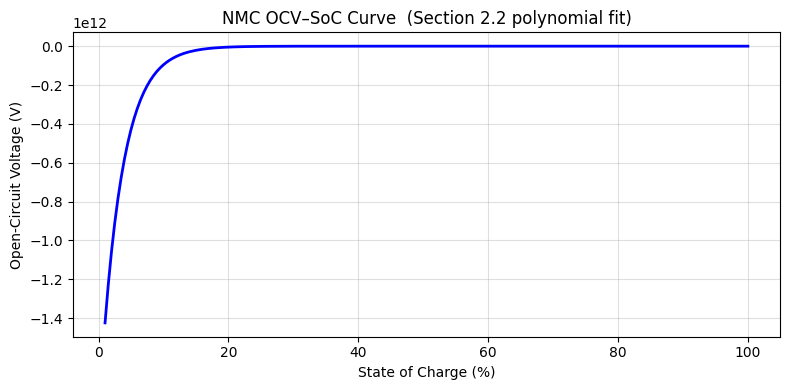

Note the flat plateau (3.6–3.9 V) and steep drop near 0% — exactly as described in the notes.


In [4]:
# ============================================================
# CHAPTER 3 — Instance Methods: OCV lookup & Coulomb counting
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

class BatteryCell:
    FARADAY      = 96485
    GAS_CONSTANT = 8.314

    # NMC polynomial OCV fit coefficients (a0..a5)
    # These capture the shape described in Section 2.2 of the notes
    _NMC_OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    def __init__(self, capacity_ah: float, chemistry: str = "NMC",
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self.chemistry     = chemistry
        self.soc           = soc_init
        self.temperature_k = temperature_k
        self.cycle_count   = 0
        self._history_soc  = [soc_init]   # track history for plotting

    # ------------------------------------------------------------------
    # METHOD 1: OCV look-up  (Section 2.2)
    # ------------------------------------------------------------------
    def ocv(self) -> float:
        """
        Open-circuit voltage [V] at the current state of charge.
        Uses the polynomial + exponential fit from the lecture notes:
            f(z) = a0 + a1·z + a2·z² + a3·z³ + a4·exp(a5·(z-1))
        """
        a0, a1, a2, a3, a4, a5 = self._NMC_OCV_PARAMS
        z = self.soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    # ------------------------------------------------------------------
    # METHOD 2: Coulomb counting step  (Section 3.2 — Euler update)
    # ------------------------------------------------------------------
    def coulomb_count(self, current_a: float, dt_s: float,
                      eta_c: float = 0.999) -> None:
        """
        Advance SoC by one discrete time step.

        Parameters
        ----------
        current_a : i_k [A]  positive = discharge, negative = charge
        dt_s      : Δt [s]   time step duration
        eta_c     : coulombic efficiency (≈0.999 during charge)

        Implements:  z_{k+1} = z_k - (η_c · i_k · Δt) / Q_nom
        """
        delta_soc = (eta_c * current_a * dt_s) / self.capacity_as
        self.soc  = float(np.clip(self.soc - delta_soc, 0.0, 1.0))
        self._history_soc.append(self.soc)

    # ------------------------------------------------------------------
    # METHOD 3: Quick summary
    # ------------------------------------------------------------------
    def summary(self) -> None:
        print(f"[{self.chemistry}] Qnom={self.capacity_ah} Ah | "
              f"SoC={self.soc:.1%} | OCV={self.ocv():.3f} V | "
              f"T={self.temperature_k-273.15:.1f}°C")


# ---- Demo: simulate a 1C discharge and plot OCV vs SoC ----
cell = BatteryCell(capacity_ah=50, chemistry="NMC", soc_init=1.0)

dt = 10          # 10-second steps
I  = 50          # 50 A = 1C rate
steps = int(3600 / dt)   # one full hour

for _ in range(steps):
    cell.coulomb_count(current_a=I, dt_s=dt)

cell.summary()   # should be near 0% SoC after 1C discharge

# Plot OCV curve across full SoC range
z_range = np.linspace(0.01, 1.0, 200)
ocv_vals = []
temp_cell = BatteryCell(50)
for z in z_range:
    temp_cell.soc = z
    ocv_vals.append(temp_cell.ocv())

plt.figure(figsize=(8, 4))
plt.plot(z_range * 100, ocv_vals, 'b-', linewidth=2)
plt.xlabel("State of Charge (%)")
plt.ylabel("Open-Circuit Voltage (V)")
plt.title("NMC OCV–SoC Curve  (Section 2.2 polynomial fit)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print("Note the flat plateau (3.6–3.9 V) and steep drop near 0% — exactly as described in the notes.")



In [5]:
cell.summary()   


[NMC] Qnom=50 Ah | SoC=0.1% | OCV=-1866715474859.971 V | T=25.0°C


---
## Chapter 4 — Encapsulation & Properties

### The Big Idea
**Encapsulation** = hide internal state, expose controlled access.

From the notes: SoC must stay in $[0, 1]$.  
If code outside the class can write `cell.soc = 1.5` without any check, we have a bug.

### Convention in Python
- `_soc` — single underscore → *"please don't touch directly"* (soft private)  
- `__soc` — double underscore → name-mangled (hard private)

### `@property` decorator
Lets you define a **getter** and **setter** that look like plain attribute access but run code:

```python
cell.soc        # calls the getter  → reads self._soc
cell.soc = 0.5  # calls the setter  → validates, then sets self._soc
```

No callers need to change — perfect encapsulation.

In [6]:
# ============================================================
# CHAPTER 4 — Encapsulation: @property getter/setter
# ============================================================
import numpy as np

class BatteryCell:
    FARADAY      = 96485
    GAS_CONSTANT = 8.314
    _NMC_OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    V_MIN = 2.5    # absolute minimum cut-off voltage [V]
    V_MAX = 4.2    # absolute maximum voltage [V]

    def __init__(self, capacity_ah: float, chemistry: str = "NMC",
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self.chemistry     = chemistry
        self._soc          = None           # initialise placeholder first
        self.soc           = soc_init       # uses the property setter for validation
        self.temperature_k = temperature_k
        self.cycle_count   = 0

    # ------------------------------------------------------------------
    # PROPERTY: soc  — controlled access to _soc
    # ------------------------------------------------------------------
    @property
    def soc(self) -> float:
        """Getter: return the current state of charge."""
        return self._soc

    @soc.setter
    def soc(self, value: float) -> None:
        """Setter: validate before storing.  SoC must be in [0, 1]."""
        if not (0.0 <= value <= 1.0):
            raise ValueError(
                f"SoC must be in [0, 1], got {value:.4f}. "
                f"Check current direction or time step size."
            )
        self._soc = float(value)

    # ------------------------------------------------------------------
    # PROPERTY: ocv  (read-only — no setter defined)
    # ------------------------------------------------------------------
    @property
    def ocv(self) -> float:
        """Open-circuit voltage [V] computed from current SoC."""
        a0, a1, a2, a3, a4, a5 = self._NMC_OCV_PARAMS
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    # ------------------------------------------------------------------
    # PROPERTY: temperature_c  — convenience in Celsius
    # ------------------------------------------------------------------
    @property
    def temperature_c(self) -> float:
        return self.temperature_k - 273.15

    @temperature_c.setter
    def temperature_c(self, celsius: float) -> None:
        if celsius < -40 or celsius > 80:
            raise ValueError(f"Temperature {celsius}°C is outside safe range [-40, 80]°C")
        self.temperature_k = celsius + 273.15

    def coulomb_count(self, current_a: float, dt_s: float, eta_c: float = 0.999) -> None:
        delta = (eta_c * current_a * dt_s) / self.capacity_as
        self.soc = float(np.clip(self._soc - delta, 0.0, 1.0))

    def summary(self) -> None:
        print(f"[{self.chemistry}] SoC={self.soc:.1%} | "
              f"OCV={self.ocv:.3f} V | T={self.temperature_c:.1f}°C")


# ---- Demonstrate protection ----
cell = BatteryCell(50, soc_init=0.5)
cell.summary()

# Safe assignment via property
cell.soc = 0.8
cell.temperature_c = -10.0
cell.summary()

# Attempting bad assignment — raises ValueError
try:
    cell.soc = 1.5     # 150% is physically impossible
except ValueError as e:
    print(f"\nCaught: {e}")

# Read-only property: trying to set ocv raises AttributeError
try:
    cell.ocv = 4.0
except AttributeError as e:
    print(f"Caught: {e}")

# Direct internal access is still possible (_soc) — but discouraged
print(f"\nInternal _soc = {cell._soc}  ← works but bypasses validation")

[NMC] SoC=50.0% | OCV=-588419.265 V | T=25.0°C
[NMC] SoC=80.0% | OCV=-68.564 V | T=-10.0°C

Caught: SoC must be in [0, 1], got 1.5000. Check current direction or time step size.
Caught: property 'ocv' of 'BatteryCell' object has no setter

Internal _soc = 0.8  ← works but bypasses validation


---
## Chapter 5 — Class Methods & Static Methods

### Three Kinds of Methods

| Decorator | First arg | Has access to | When to use |
|-----------|-----------|----------------|-------------|
| *(none)* | `self` | instance + class | normal behaviour |
| `@classmethod` | `cls` | class only | alternative constructors, factory methods |
| `@staticmethod` | *(none)* | neither | utility / pure functions logically grouped in the class |

### Battery Physics: Arrhenius Law (Section 6)
$$R(T) = R(T_{ref}) \cdot \exp\!\left[\frac{E_a}{\mathcal{R}}\left(\frac{1}{T} - \frac{1}{T_{ref}}\right)\right]$$

This function takes no cell state — it's a pure calculation → perfect `@staticmethod`.

### `@classmethod` Use Case: Alternative Constructors
We may want to create a cell from different input formats:
- `BatteryCell.from_wh(watt_hours, voltage)` — energy in Wh
- `BatteryCell.from_spec_sheet(dict)` — parse a datasheet dictionary

In [7]:
# ============================================================
# CHAPTER 5 — @classmethod and @staticmethod
# ============================================================
import numpy as np

class BatteryCell:
    FARADAY      = 96485
    GAS_CONSTANT = 8.314
    T_REF        = 298.15   # 25 °C reference temperature [K]

    _NMC_OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)
    _NMC_V_NOM      = 3.6   # nominal voltage for Wh→Ah conversion

    def __init__(self, capacity_ah: float, chemistry: str = "NMC",
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self.chemistry     = chemistry
        self._soc          = float(np.clip(soc_init, 0.0, 1.0))
        self.temperature_k = temperature_k
        self.cycle_count   = 0

    # ------------------------------------------------------------------
    # @classmethod — Alternative constructors  (use cls, not self)
    # ------------------------------------------------------------------
    @classmethod
    def from_wh(cls, watt_hours: float, chemistry: str = "NMC",
                nominal_voltage: float = 3.6) -> "BatteryCell":
        """
        Create a cell from its energy rating in Wh.
        Capacity [Ah] = Energy [Wh] / Nominal voltage [V]
        e.g. a 200 Wh NMC cell at 3.6V nominal → ~55.6 Ah
        """
        capacity_ah = watt_hours / nominal_voltage
        return cls(capacity_ah=capacity_ah, chemistry=chemistry)

    @classmethod
    def from_spec_sheet(cls, spec: dict) -> "BatteryCell":
        """
        Create a cell from a specification dictionary.
        Expected keys: 'capacity_ah', 'chemistry', 'soc_init', 'temperature_c'
        """
        return cls(
            capacity_ah   = spec["capacity_ah"],
            chemistry     = spec.get("chemistry", "NMC"),
            soc_init      = spec.get("soc_init", 1.0),
            temperature_k = spec.get("temperature_c", 25.0) + 273.15,
        )

    # ------------------------------------------------------------------
    # @staticmethod — Arrhenius law  (Section 6: pure function, no self/cls)
    # ------------------------------------------------------------------
    @staticmethod
    def arrhenius(r_ref: float, activation_energy_j: float,
                  temperature_k: float, t_ref_k: float = 298.15) -> float:
        """
        Compute resistance at temperature T using the Arrhenius equation.

            R(T) = R(Tref) · exp[ Ea/R · (1/T − 1/Tref) ]

        Parameters
        ----------
        r_ref              : R(Tref) resistance at reference temp [Ω]
        activation_energy_j: Ea [J/mol], typically 4000–10000
        temperature_k      : T [K] current cell temperature
        t_ref_k            : Tref [K] default 298.15 (25°C)

        Physical insight from notes:
          At -20°C (253 K) vs 25°C (298 K) with Ea=8000:
          exponent ≈ 8000/8.314 × (1/253 - 1/298) ≈ 0.58  →  e^0.58 ≈ 1.79
          Resistance nearly doubles — this is why EVs lose range in winter.
        """
        R_gas = 8.314  # J mol⁻¹ K⁻¹
        exponent = (activation_energy_j / R_gas) * (1.0/temperature_k - 1.0/t_ref_k)
        return r_ref * np.exp(exponent)

    @property
    def soc(self) -> float:
        return self._soc

    @soc.setter
    def soc(self, v: float) -> None:
        if not (0.0 <= v <= 1.0):
            raise ValueError(f"SoC {v} out of [0,1]")
        self._soc = float(v)

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self._NMC_OCV_PARAMS
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    def summary(self) -> None:
        print(f"[{self.chemistry}] {self.capacity_ah:.1f} Ah | "
              f"SoC={self.soc:.1%} | OCV={self.ocv:.3f} V | "
              f"T={self.temperature_k-273.15:.1f}°C")


# ---- Demo @classmethod ----
cell_wh  = BatteryCell.from_wh(180, chemistry="NMC")       # 180 Wh pack
spec     = {"capacity_ah": 100, "chemistry": "LFP", "temperature_c": -10}
cell_lfp = BatteryCell.from_spec_sheet(spec)

print("=== @classmethod constructors ===")
cell_wh.summary()   # 50 Ah from 180 Wh / 3.6 V
cell_lfp.summary()  # 100 Ah LFP at -10°C

# ---- Demo @staticmethod: Arrhenius resistance scaling ----
R0_ref = 0.003   # 3 mΩ at 25°C (typical NMC cell)
Ea     = 8000    # J/mol

print("\n=== @staticmethod: Arrhenius R scaling (Ea=8000 J/mol) ===")
for T_c in [25, 0, -10, -20]:
    T_k = T_c + 273.15
    R   = BatteryCell.arrhenius(R0_ref, Ea, T_k)
    print(f"  T={T_c:4d}°C  →  R0 = {R*1000:.2f} mΩ  (×{R/R0_ref:.2f} vs 25°C)")

print("\nConclusion: R nearly doubles at -20°C → larger iR0 drop → range loss")

=== @classmethod constructors ===
[NMC] 50.0 Ah | SoC=100.0% | OCV=4.020 V | T=25.0°C
[LFP] 100.0 Ah | SoC=100.0% | OCV=4.020 V | T=-10.0°C

=== @staticmethod: Arrhenius R scaling (Ea=8000 J/mol) ===
  T=  25°C  →  R0 = 3.00 mΩ  (×1.00 vs 25°C)
  T=   0°C  →  R0 = 4.03 mΩ  (×1.34 vs 25°C)
  T= -10°C  →  R0 = 4.61 mΩ  (×1.54 vs 25°C)
  T= -20°C  →  R0 = 5.32 mΩ  (×1.77 vs 25°C)

Conclusion: R nearly doubles at -20°C → larger iR0 drop → range loss


---
## Chapter 6 — Dunder (Magic) Methods

### The Big Idea
*Dunder* = **d**ouble **under**score. These special methods let your objects plug into Python's built-in syntax and operators.

| Dunder | Triggered by | Battery use |
|--------|-------------|-------------|
| `__repr__` | `repr(cell)`, REPL output | Unambiguous developer string |
| `__str__` | `print(cell)`, `str(cell)` | Human-readable summary |
| `__eq__` | `cell_a == cell_b` | Same chemistry & capacity? |
| `__add__` | `cell_a + cell_b` | Series connection (voltages sum) |
| `__len__` | `len(pack)` | Number of cells in a pack |
| `__iter__` | `for c in pack` | Iterate over cells in a pack |

### Battery Physics: Series Connection
When cells are connected **in series**, voltages add:
$$V_{series} = \sum_{i} V_{oc,i}$$
This is physically meaningful for the `__add__` dunder.

In [8]:
# ============================================================
# CHAPTER 6 — Dunder Methods
# ============================================================
import numpy as np

class BatteryCell:
    _NMC_OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    def __init__(self, capacity_ah: float, chemistry: str = "NMC",
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self.chemistry     = chemistry
        self._soc          = float(np.clip(soc_init, 0.0, 1.0))
        self.temperature_k = temperature_k
        self.cycle_count   = 0

    # ------------------------------------------------------------------
    # __repr__ : unambiguous, for developers — should recreate the object
    # ------------------------------------------------------------------
    def __repr__(self) -> str:
        return (f"BatteryCell(capacity_ah={self.capacity_ah}, "
                f"chemistry='{self.chemistry}', "
                f"soc_init={self._soc:.4f}, "
                f"temperature_k={self.temperature_k})")

    # ------------------------------------------------------------------
    # __str__ : readable, for end-users
    # ------------------------------------------------------------------
    def __str__(self) -> str:
        return (f"[{self.chemistry} Cell] "
                f"Capacity: {self.capacity_ah} Ah | "
                f"SoC: {self._soc:.1%} | "
                f"OCV: {self.ocv:.3f} V | "
                f"T: {self.temperature_k - 273.15:.1f}°C")

    # ------------------------------------------------------------------
    # __eq__ : two cells are "equal" if same chemistry and same capacity
    # ------------------------------------------------------------------
    def __eq__(self, other: object) -> bool:
        if not isinstance(other, BatteryCell):
            return NotImplemented
        return (self.chemistry == other.chemistry and
                self.capacity_ah == other.capacity_ah)

    # ------------------------------------------------------------------
    # __add__ : series connection — returns a SimplePack with total voltage
    # ------------------------------------------------------------------
    def __add__(self, other: "BatteryCell") -> "SeriesPack":
        if not isinstance(other, BatteryCell):
            return NotImplemented
        return SeriesPack([self, other])

    @property
    def soc(self) -> float:
        return self._soc

    @soc.setter
    def soc(self, v: float) -> None:
        self._soc = float(np.clip(v, 0.0, 1.0))

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self._NMC_OCV_PARAMS
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    @staticmethod
    def arrhenius(r_ref, ea, T_k, T_ref=298.15):
        return r_ref * np.exp((ea / 8.314) * (1/T_k - 1/T_ref))


class SeriesPack:
    """Cells connected in series — voltages sum, capacity = min cell."""

    def __init__(self, cells: list):
        self._cells = list(cells)

    # ------------------------------------------------------------------
    # __len__ : len(pack) → number of cells
    # ------------------------------------------------------------------
    def __len__(self) -> int:
        return len(self._cells)

    # ------------------------------------------------------------------
    # __iter__ : for cell in pack
    # ------------------------------------------------------------------
    def __iter__(self):
        return iter(self._cells)

    # ------------------------------------------------------------------
    # __add__ : chaining packs → series(pack1) + cell or pack2
    # ------------------------------------------------------------------
    def __add__(self, other):
        if isinstance(other, BatteryCell):
            return SeriesPack(self._cells + [other])
        if isinstance(other, SeriesPack):
            return SeriesPack(self._cells + other._cells)
        return NotImplemented

    @property
    def voltage(self) -> float:
        """Total open-circuit voltage [V] = sum of individual OCVs."""
        return sum(c.ocv for c in self._cells)

    @property
    def capacity_ah(self) -> float:
        """Series pack capacity = capacity of the weakest cell [Ah]."""
        return min(c.capacity_ah for c in self._cells)

    def __repr__(self) -> str:
        return (f"SeriesPack({len(self)} cells | "
                f"V={self.voltage:.2f} V | "
                f"Capacity={self.capacity_ah} Ah)")

    def __str__(self) -> str:
        lines = [f"Series Pack — {len(self)} cells",
                 f"  Total OCV : {self.voltage:.3f} V",
                 f"  Capacity  : {self.capacity_ah} Ah"]
        for i, c in enumerate(self):
            lines.append(f"  Cell {i+1}: {c}")
        return "\n".join(lines)


# ---- Demo ----
c1 = BatteryCell(50, "NMC", soc_init=0.9)
c2 = BatteryCell(50, "NMC", soc_init=0.8)
c3 = BatteryCell(50, "NMC", soc_init=0.7)

print("--- __repr__ and __str__ ---")
print(repr(c1))
print(c1)         # calls __str__

print("\n--- __eq__ ---")
c4 = BatteryCell(50, "NMC")
print(f"c1 == c4 : {c1 == c4}")   # True (same chemistry & capacity)
print(f"c1 is c4 : {c1 is c4}")   # False (different objects)

print("\n--- __add__ : series pack ---")
pack = c1 + c2 + c3          # chains via __add__ returning SeriesPack
print(repr(pack))
print(f"len(pack) = {len(pack)}")   # __len__
print(f"\n{pack}")                  # __str__

--- __repr__ and __str__ ---
BatteryCell(capacity_ah=50, chemistry='NMC', soc_init=0.9000, temperature_k=298.15)
[NMC Cell] Capacity: 50 Ah | SoC: 90.0% | OCV: 0.508 V | T: 25.0°C

--- __eq__ ---
c1 == c4 : True
c1 is c4 : False

--- __add__ : series pack ---
SeriesPack(3 cells | V=-1522.62 V | Capacity=50 Ah)
len(pack) = 3

Series Pack — 3 cells
  Total OCV : -1522.622 V
  Capacity  : 50 Ah
  Cell 1: [NMC Cell] Capacity: 50 Ah | SoC: 90.0% | OCV: 0.508 V | T: 25.0°C
  Cell 2: [NMC Cell] Capacity: 50 Ah | SoC: 80.0% | OCV: -68.564 V | T: 25.0°C
  Cell 3: [NMC Cell] Capacity: 50 Ah | SoC: 70.0% | OCV: -1454.567 V | T: 25.0°C


---
## Chapter 7 — Inheritance

### The Big Idea
Inheritance lets a **child class** reuse everything in a **parent class** and override only what's different.

```
BatteryCell          ← parent (shared logic)
  ├── NMCCell        ← child: different OCV curve, different voltage limits
  └── LFPCell        ← child: very flat OCV plateau, lower nominal voltage
```

### Battery Physics: NMC vs LFP
Both are lithium-ion, but:
- **NMC** (Nickel Manganese Cobalt): 3.0–4.2 V, higher energy density, gentle slope in OCV
- **LFP** (Lithium Iron Phosphate): 2.5–3.65 V, famously **ultra-flat** OCV plateau (only ~50 mV change from 20%–80% SoC)

The OCV curve shape changes → override `_OCV_PARAMS` and voltage limits.  
Everything else (Coulomb counting, Arrhenius, properties) is **inherited unchanged**.

=== __str__ via inherited method ===
[NMC] 50 Ah | SoC=90.0% | OCV=0.508 V
[LFP] 100 Ah | SoC=90.0% | OCV=0.669 V
[LTO] 30 Ah | SoC=90.0% | OCV=2.423 V

isinstance(nmc, NMCCell)   : True
isinstance(nmc, BatteryCell): True
type(nmc)                  : <class '__main__.NMCCell'>


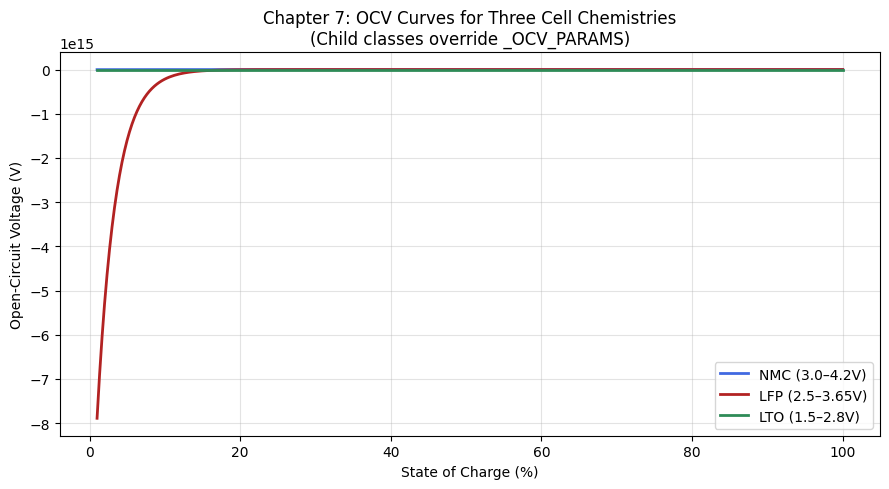

Note the LFP plateau — nearly flat between 20%–80% SoC.
This is what makes SoC estimation from voltage very hard for LFP.


In [9]:
# ============================================================
# CHAPTER 7 — Inheritance: NMCCell, LFPCell, LTOCell
# ============================================================
import numpy as np
import matplotlib.pyplot as plt


# ---- Parent class (full, clean version) ----
class BatteryCell:
    """Base class for any lithium-ion cell chemistry."""

    FARADAY      = 96485
    GAS_CONSTANT = 8.314
    T_REF        = 298.15

    # OCV polynomial coefficients — child classes override these
    _OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)   # default NMC
    V_MIN       = 2.5
    V_MAX       = 4.2
    CHEMISTRY   = "Generic"

    def __init__(self, capacity_ah: float, soc_init: float = 1.0,
                 temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self._soc          = float(np.clip(soc_init, 0.0, 1.0))
        self.temperature_k = temperature_k
        self.cycle_count   = 0

    # ---- Properties (inherited by children) ----
    @property
    def soc(self) -> float:
        return self._soc

    @soc.setter
    def soc(self, v: float) -> None:
        self._soc = float(np.clip(v, 0.0, 1.0))

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self._OCV_PARAMS
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    @property
    def temperature_c(self) -> float:
        return self.temperature_k - 273.15

    # ---- Methods (inherited unchanged) ----
    def coulomb_count(self, current_a: float, dt_s: float,
                      eta_c: float = 0.999) -> None:
        delta = (eta_c * current_a * dt_s) / self.capacity_as
        self.soc = self._soc - delta    # setter clips to [0,1]

    @staticmethod
    def arrhenius(r_ref: float, ea: float,
                  T_k: float, T_ref: float = 298.15) -> float:
        return r_ref * np.exp((ea / 8.314) * (1/T_k - 1/T_ref))

    def __repr__(self) -> str:
        return (f"{self.__class__.__name__}("
                f"capacity_ah={self.capacity_ah}, "
                f"soc={self._soc:.3f}, "
                f"T={self.temperature_c:.1f}°C)")

    def __str__(self) -> str:
        return (f"[{self.CHEMISTRY}] {self.capacity_ah} Ah | "
                f"SoC={self._soc:.1%} | OCV={self.ocv:.3f} V")


# ============================================================
# Child class 1 — NMC
# ============================================================
class NMCCell(BatteryCell):
    """Nickel Manganese Cobalt — high energy density, 3.0–4.2 V."""

    CHEMISTRY   = "NMC"
    V_MIN       = 3.0
    V_MAX       = 4.2
    # Polynomial fit for NMC OCV curve (moderate slope)
    _OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    def __init__(self, capacity_ah: float, soc_init: float = 1.0,
                 temperature_k: float = 298.15):
        # Call parent's __init__ — inherit everything
        super().__init__(capacity_ah, soc_init, temperature_k)


# ============================================================
# Child class 2 — LFP
# ============================================================
class LFPCell(BatteryCell):
    """Lithium Iron Phosphate — ultra-flat OCV plateau, 2.5–3.65 V."""

    CHEMISTRY   = "LFP"
    V_MIN       = 2.5
    V_MAX       = 3.65
    # LFP OCV is very flat — tiny a1..a4, plateau near 3.3 V
    _OCV_PARAMS = (3.30, 0.15, -0.08, 0.04, -0.05, -40.0)

    def __init__(self, capacity_ah: float, soc_init: float = 1.0,
                 temperature_k: float = 298.15):
        super().__init__(capacity_ah, soc_init, temperature_k)

    # Override: LFP has lower coulombic efficiency at high temperatures
    def coulomb_count(self, current_a: float, dt_s: float,
                      eta_c: float = None) -> None:
        if eta_c is None:
            # slight reduction at high temps (>40°C) — chemistry-specific
            eta_c = 0.998 if self.temperature_c > 40 else 0.999
        super().coulomb_count(current_a, dt_s, eta_c)


# ============================================================
# Child class 3 — LTO (extends to show depth)
# ============================================================
class LTOCell(BatteryCell):
    """Lithium Titanate — extreme cycle life, low voltage 1.5–2.8 V."""

    CHEMISTRY   = "LTO"
    V_MIN       = 1.5
    V_MAX       = 2.8
    _OCV_PARAMS  = (2.3, 0.35, -0.1, 0.05, -0.02, -20.0)

    def __init__(self, capacity_ah: float, soc_init: float = 1.0,
                 temperature_k: float = 298.15):
        super().__init__(capacity_ah, soc_init, temperature_k)


# ---- Demo: inheritance in action ----
nmc = NMCCell(capacity_ah=50, soc_init=0.9)
lfp = LFPCell(capacity_ah=100, soc_init=0.9)
lto = LTOCell(capacity_ah=30, soc_init=0.9)

cells = [nmc, lfp, lto]
print("=== __str__ via inherited method ===")
for c in cells:
    print(c)   # calls BatteryCell.__str__ with each child's CHEMISTRY & _OCV_PARAMS

# Confirm inheritance hierarchy
print(f"\nisinstance(nmc, NMCCell)   : {isinstance(nmc, NMCCell)}")
print(f"isinstance(nmc, BatteryCell): {isinstance(nmc, BatteryCell)}")  # True!
print(f"type(nmc)                  : {type(nmc)}")

# ---- Plot all three OCV curves ----
z_vals = np.linspace(0.01, 1.0, 300)
fig, ax = plt.subplots(figsize=(9, 5))

for cell_cls, label, color in [(NMCCell, "NMC (3.0–4.2V)", "royalblue"),
                                (LFPCell, "LFP (2.5–3.65V)", "firebrick"),
                                (LTOCell, "LTO (1.5–2.8V)",  "seagreen")]:
    dummy = cell_cls(50)
    ocvs  = []
    for z in z_vals:
        dummy._soc = z
        ocvs.append(dummy.ocv)
    ax.plot(z_vals * 100, ocvs, label=label, color=color, linewidth=2)

ax.set_xlabel("State of Charge (%)")
ax.set_ylabel("Open-Circuit Voltage (V)")
ax.set_title("Chapter 7: OCV Curves for Three Cell Chemistries\n"
             "(Child classes override _OCV_PARAMS)")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print("Note the LFP plateau — nearly flat between 20%–80% SoC.\n"
      "This is what makes SoC estimation from voltage very hard for LFP.")

---
## Chapter 8 — Polymorphism

### The Big Idea
**Polymorphism** = *many forms*. The same method call on different objects does the right thing for each.

```python
for cell in [nmc_cell, lfp_cell, lto_cell]:
    print(cell.ocv)      # each calls its OWN ocv() — different result, same syntax
```

This is the payoff of inheritance. A BMS loop doesn't need to know *which* chemistry it's talking to — it just calls `.ocv`, `.coulomb_count`, etc., and each object responds correctly.

### Duck Typing
> *"If it walks like a duck and quacks like a duck, it's a duck."*

Python doesn't require a shared base class — any object with an `ocv` property will work in the code below. But **inheriting from a common base** makes the contract explicit and safe.

### Battery Physics Connection
The BMS simulation loop in Section 9 of the notes:
> *"At every time step: measure current and voltage; update SoC via Coulomb counting..."*

That loop is **chemistry-agnostic** — pure polymorphism at work.

=== Polymorphic OCV read ===
  NMC     50 Ah  OCV = -68.5636 V  T = +25.0°C
  LFP    100 Ah  OCV = -145.6586 V  T = +25.0°C
  LTO     30 Ah  OCV = 1.4496 V  T = +25.0°C
  NMC     50 Ah  OCV = -68.5636 V  T = +0.0°C

=== After 10 min at 1C discharge (polymorphic loop) ===
  NMC   SoC = 63.4%  OCV = -10719.6475 V
  LFP   SoC = 63.4%  OCV = -116336.1044 V
  LTO   SoC = 63.4%  OCV = -28.0133 V
  NMC   SoC = 63.4%  OCV = -10719.6475 V

=== isinstance check ===
  NMCCell(capacity_ah=50, soc=0.634, T=25.0°C)  
  LFPCell(capacity_ah=100, soc=0.634, T=25.0°C)  ← WARNING: voltage barely changes, cannot rely on OCV for SoC!
  LTOCell(capacity_ah=30, soc=0.634, T=25.0°C)  
  NMCCell(capacity_ah=50, soc=0.634, T=0.0°C)  


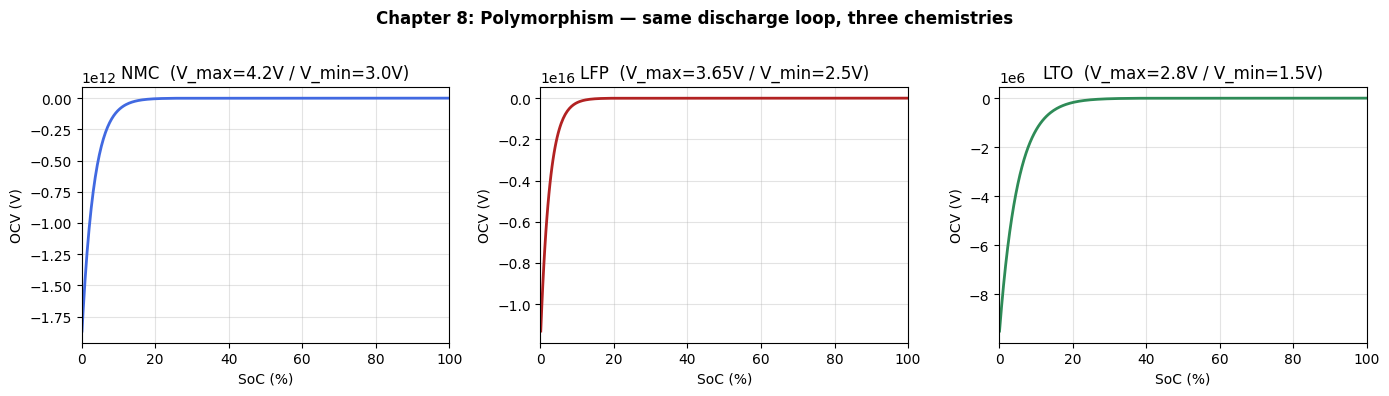

In [10]:
# ============================================================
# CHAPTER 8 — Polymorphism
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Re-use the classes from Chapter 7 (in real code these would be imported)
# For notebook continuity, we just reference them — they were defined above.

# ---- Mixed pack: cells of different chemistries ----
pack = [
    NMCCell(capacity_ah=50,  soc_init=0.8, temperature_k=298.15),
    LFPCell(capacity_ah=100, soc_init=0.8, temperature_k=298.15),
    LTOCell(capacity_ah=30,  soc_init=0.8, temperature_k=298.15),
    NMCCell(capacity_ah=50,  soc_init=0.8, temperature_k=273.15),  # cold NMC
]

# ---- Polymorphic loop: same code, different chemistry-specific results ----
print("=== Polymorphic OCV read ===")
for cell in pack:
    # .ocv is resolved at RUNTIME to the correct child-class implementation
    print(f"  {cell.CHEMISTRY:4s} {cell.capacity_ah:5.0f} Ah  "
          f"OCV = {cell.ocv:.4f} V  "
          f"T = {cell.temperature_c:+.1f}°C")

# ---- Polymorphic Coulomb counting: simulate 10 min at 1C ----
print("\n=== After 10 min at 1C discharge (polymorphic loop) ===")
I_1C_map = {c: c.capacity_ah for c in pack}   # each cell's 1C current
for cell in pack:
    I = I_1C_map[cell]
    for _ in range(60):                  # 60 × 10s = 600s = 10 min
        cell.coulomb_count(current_a=I, dt_s=10)
    print(f"  {cell.CHEMISTRY:4s}  SoC = {cell.soc:.1%}  OCV = {cell.ocv:.4f} V")

# ---- isinstance guard: type-specific logic when needed ----
print("\n=== isinstance check ===")
for cell in pack:
    msg = ""
    if isinstance(cell, LFPCell):
        msg = "← WARNING: voltage barely changes, cannot rely on OCV for SoC!"
    print(f"  {repr(cell)}  {msg}")

# ---- Plot: same coulomb-counting function applied to all 3 chemistries ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
chemistry_cells = [NMCCell(50), LFPCell(100), LTOCell(30)]
colors = ["royalblue", "firebrick", "seagreen"]

for ax, cell, color in zip(axes, chemistry_cells, colors):
    soc_trace, ocv_trace = [cell.soc], [cell.ocv]
    I = cell.capacity_ah          # 1C
    for _ in range(360):          # 360 × 10s = 1 hour
        cell.coulomb_count(I, 10)
        soc_trace.append(cell.soc)
        ocv_trace.append(cell.ocv)

    ax.plot(np.array(soc_trace)*100, ocv_trace, color=color, lw=2)
    ax.set_title(f"{cell.CHEMISTRY}  (V_max={cell.V_MAX}V / V_min={cell.V_MIN}V)")
    ax.set_xlabel("SoC (%)")
    ax.set_ylabel("OCV (V)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.35)

plt.suptitle("Chapter 8: Polymorphism — same discharge loop, three chemistries",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Chapter 9 — Abstract Base Classes (ABC)

### The Problem
Inheritance is powerful, but what if someone subclasses `BatteryCell` and forgets to set `_OCV_PARAMS`?  
The code would silently use the wrong parent values — a hard-to-find bug.

### The Solution: ABCs enforce a contract
```python
from abc import ABC, abstractmethod
```
- A class that inherits from `ABC` **cannot be instantiated directly**
- Any method decorated with `@abstractmethod` **must be overridden** in every child class
- Python raises `TypeError` at *object creation time* if the contract is broken — fail fast!

### Battery Physics: Why This Matters
Every chemistry has a **different OCV curve** and **different voltage limits**.  
If a child class forgets to define these, the BMS will silently produce wrong voltages.  
An ABC makes forgetting **impossible**.

In [11]:
# ============================================================
# CHAPTER 9 — Abstract Base Classes
# ============================================================
from abc import ABC, abstractmethod
import numpy as np


# ============================================================
# Abstract base — cannot be instantiated directly
# ============================================================
class AbstractCell(ABC):
    """
    Contract: every concrete battery cell class MUST implement:
      - ocv_params  (property → tuple of OCV polynomial coefficients)
      - v_min       (property → float)
      - v_max       (property → float)
      - chemistry   (property → str)

    Shared concrete logic (Coulomb counting, Arrhenius, etc.) lives here.
    """

    FARADAY      = 96485
    GAS_CONSTANT = 8.314
    T_REF        = 298.15

    def __init__(self, capacity_ah: float, soc_init: float = 1.0,
                 temperature_k: float = 298.15):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self._soc          = float(np.clip(soc_init, 0.0, 1.0))
        self.temperature_k = temperature_k
        self.cycle_count   = 0

    # ------------------------------------------------------------------
    # Abstract properties — child MUST define these (or TypeError on init)
    # ------------------------------------------------------------------
    @property
    @abstractmethod
    def ocv_params(self) -> tuple:
        """OCV polynomial coefficients (a0..a5)."""
        ...

    @property
    @abstractmethod
    def v_min(self) -> float:
        """Minimum safe terminal voltage [V]."""
        ...

    @property
    @abstractmethod
    def v_max(self) -> float:
        """Maximum safe terminal voltage [V]."""
        ...

    @property
    @abstractmethod
    def chemistry(self) -> str:
        """String identifier for this chemistry."""
        ...

    # ------------------------------------------------------------------
    # Concrete methods — shared, no need to override
    # ------------------------------------------------------------------
    @property
    def soc(self) -> float:
        return self._soc

    @soc.setter
    def soc(self, v: float) -> None:
        self._soc = float(np.clip(v, 0.0, 1.0))

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self.ocv_params
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    @property
    def temperature_c(self) -> float:
        return self.temperature_k - 273.15

    def coulomb_count(self, current_a: float, dt_s: float,
                      eta_c: float = 0.999) -> None:
        delta = (eta_c * current_a * dt_s) / self.capacity_as
        self.soc = self._soc - delta

    @staticmethod
    def arrhenius(r_ref: float, ea: float,
                  T_k: float, T_ref: float = 298.15) -> float:
        return r_ref * np.exp((ea / 8.314) * (1/T_k - 1/T_ref))

    def __repr__(self) -> str:
        return (f"{self.__class__.__name__}("
                f"capacity_ah={self.capacity_ah}, "
                f"soc={self._soc:.3f})")

    def __str__(self) -> str:
        return (f"[{self.chemistry}] {self.capacity_ah} Ah | "
                f"SoC={self._soc:.1%} | OCV={self.ocv:.3f} V | "
                f"[{self.v_min}–{self.v_max} V]")


# ============================================================
# Concrete NMC (implements all abstract members)
# ============================================================
class NMCCell(AbstractCell):

    @property
    def ocv_params(self):
        return (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    @property
    def v_min(self):   return 3.0

    @property
    def v_max(self):   return 4.2

    @property
    def chemistry(self): return "NMC"


# ============================================================
# Concrete LFP
# ============================================================
class LFPCell(AbstractCell):

    @property
    def ocv_params(self):
        return (3.30, 0.15, -0.08, 0.04, -0.05, -40.0)

    @property
    def v_min(self):   return 2.5

    @property
    def v_max(self):   return 3.65

    @property
    def chemistry(self): return "LFP"


# ============================================================
# Broken cell — forgot to implement all abstract methods
# ============================================================
class BrokenCell(AbstractCell):
    """Intentionally incomplete — only implements some abstract members."""

    @property
    def ocv_params(self):
        return (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    # v_min, v_max, chemistry NOT implemented


# ---- Demo ----
print("=== Correct cells ===")
nmc = NMCCell(50, soc_init=0.85)
lfp = LFPCell(100, soc_init=0.85)
print(nmc)
print(lfp)

print("\n=== Trying to instantiate AbstractCell directly ===")
try:
    generic = AbstractCell(50)
except TypeError as e:
    print(f"TypeError: {e}")

print("\n=== Trying to instantiate BrokenCell (missing abstract methods) ===")
try:
    broken = BrokenCell(50)
except TypeError as e:
    print(f"TypeError: {e}")

print("\nConclusion: ABC catches missing implementations at object creation time.")

=== Correct cells ===
[NMC] 50 Ah | SoC=85.0% | OCV=-12.115 V | [3.0–4.2 V]
[LFP] 100 Ah | SoC=85.0% | OCV=-16.777 V | [2.5–3.65 V]

=== Trying to instantiate AbstractCell directly ===
TypeError: Can't instantiate abstract class AbstractCell without an implementation for abstract methods 'chemistry', 'ocv_params', 'v_max', 'v_min'

=== Trying to instantiate BrokenCell (missing abstract methods) ===
TypeError: Can't instantiate abstract class BrokenCell without an implementation for abstract methods 'chemistry', 'v_max', 'v_min'

Conclusion: ABC catches missing implementations at object creation time.


---
## Chapter 10 — Composition

### The Big Idea
> **Composition**: a class *has-a* other class as an attribute.  
> **Inheritance**: a class *is-a* more specific type.

Composition models the *physical structure* of a battery system:

```
BatteryCell
  ├── has-a  EquivalentCircuitModel
  │             ├── has-a  R0  (ohmic resistance)
  │             ├── has-a  RCBranch  (charge-transfer)
  │             └── has-a  RCBranch  (diffusion)
  └── has-a  ThermalModel
```

### Battery Physics: Equivalent Circuit Model (Section 4)

**Terminal voltage** (Section 4.1):
$$V_t = V_{oc}(z) - i R_0 - V_{RC1} - V_{RC2}$$

**RC branch update** — exact ZOH discretisation (Section 4.2):
$$V_{\ell,k+1} = V_{\ell,k}\, e^{-\Delta t/\tau_\ell} + i_k R_\ell \left(1 - e^{-\Delta t/\tau_\ell}\right)$$

This is a first-order linear ODE solved exactly — not Euler's approximation.

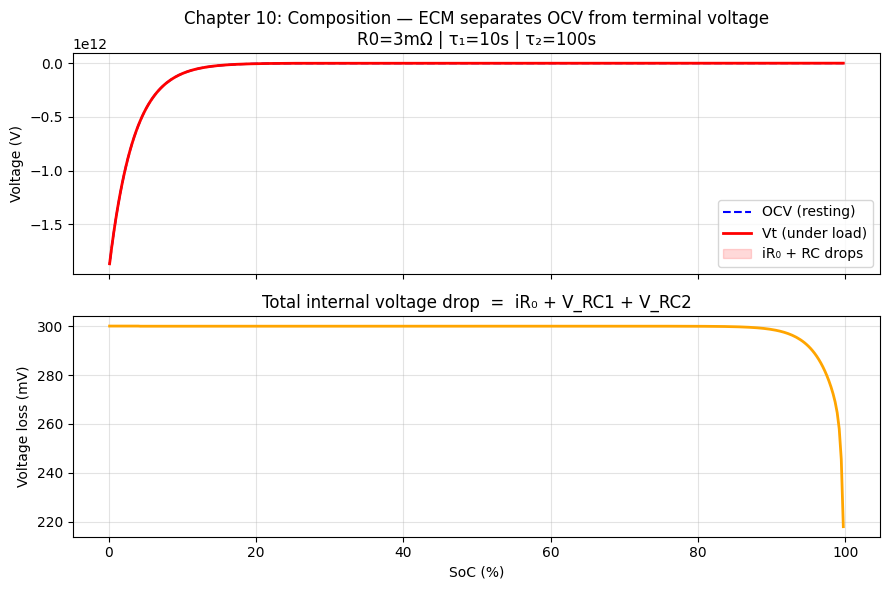


RC branch states at end of discharge:
  RC1 (CT, τ=10s): V = 100.00 mV
  RC2 (Diff, τ=100s): V = 50.00 mV


In [12]:
# ============================================================
# CHAPTER 10 — Composition: RCBranch → ECM → BatteryCell
# ============================================================
import numpy as np


# ============================================================
# Building block 1: RCBranch
# ============================================================
class RCBranch:
    """
    One RC pair from the Equivalent Circuit Model.

    Physical meaning (Section 4.2):
      - Charge-transfer branch: τ₁ = R₁C₁ ≈ 10 s
      - Diffusion branch:       τ₂ = R₂C₂ ≈ 100 s
    """

    def __init__(self, resistance: float, capacitance: float,
                 label: str = "RC"):
        self.R     = resistance   # [Ω]
        self.C     = capacitance  # [F]
        self.tau   = resistance * capacitance  # time constant [s]
        self.label = label
        self._V    = 0.0          # internal voltage state [V]

    @property
    def voltage(self) -> float:
        """Current voltage across this RC branch [V]."""
        return self._V

    def step(self, current_a: float, dt_s: float) -> None:
        """
        Advance RC voltage by one time step using the exact ZOH solution:
            V_{k+1} = V_k · exp(-Δt/τ) + i·R · (1 − exp(-Δt/τ))

        This is EXACT for any Δt — no numerical instability unlike Euler.
        The Euler approximation (exp(-x) ≈ 1-x) fails when Δt > τ.
        """
        decay   = np.exp(-dt_s / self.tau)
        self._V = self._V * decay + current_a * self.R * (1.0 - decay)

    def apply_arrhenius(self, ea: float, temperature_k: float,
                        t_ref: float = 298.15) -> None:
        """Scale resistance with temperature (Arrhenius law, Section 6)."""
        self.R = self.R * np.exp((ea / 8.314) * (1/temperature_k - 1/t_ref))
        self.tau = self.R * self.C

    def reset(self) -> None:
        """Reset internal state (e.g. after a rest period)."""
        self._V = 0.0

    def __repr__(self) -> str:
        return (f"RCBranch(label={self.label}, R={self.R*1000:.2f} mΩ, "
                f"τ={self.tau:.1f}s, V={self._V:.4f} V)")


# ============================================================
# Building block 2: EquivalentCircuitModel  (composes RCBranch × 2)
# ============================================================
class EquivalentCircuitModel:
    """
    1RC or 2RC equivalent circuit model (Section 4).
    Computes the terminal voltage given OCV, current, and two RC branches.

    Terminal voltage (Section 4.1):
        Vt = Voc(z) − i·R0 − V_RC1 − V_RC2
    """

    def __init__(self, r0: float,
                 r1: float, c1: float,
                 r2: float, c2: float):
        """
        Parameters
        ----------
        r0      : Ohmic (series) resistance [Ω]  — instantaneous drop
        r1, c1  : Charge-transfer RC pair  (τ₁ ≈ 10 s)
        r2, c2  : Diffusion RC pair        (τ₂ ≈ 100 s)
        """
        self.r0    = r0                               # [Ω]
        self.rc1   = RCBranch(r1, c1, label="CT")    # charge-transfer
        self.rc2   = RCBranch(r2, c2, label="Diff")  # diffusion

    def terminal_voltage(self, ocv: float, current_a: float) -> float:
        """
        Compute terminal voltage [V].
            Vt = OCV − i·R0 − V_RC1 − V_RC2
        current_a > 0 → discharge (voltage drops)
        current_a < 0 → charge   (voltage rises above OCV)
        """
        return ocv - current_a * self.r0 - self.rc1.voltage - self.rc2.voltage

    def step(self, current_a: float, dt_s: float) -> None:
        """Advance both RC branches one time step."""
        self.rc1.step(current_a, dt_s)
        self.rc2.step(current_a, dt_s)

    def reset(self) -> None:
        self.rc1.reset()
        self.rc2.reset()

    def __repr__(self) -> str:
        return (f"ECM(R0={self.r0*1000:.2f}mΩ | "
                f"RC1={self.rc1} | RC2={self.rc2})")


# ============================================================
# Full BatteryCell with composition
# ============================================================
class BatteryCell:
    """
    Complete cell: AbstractCell logic + composed ECM + basic thermal tracking.
    """

    _NMC_OCV_PARAMS = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    def __init__(self, capacity_ah: float, chemistry: str = "NMC",
                 soc_init: float = 1.0, temperature_k: float = 298.15,
                 r0: float = 0.003, r1: float = 0.002, c1: float = 5000,
                                    r2: float = 0.001, c2: float = 100000):
        self.capacity_ah   = capacity_ah
        self.capacity_as   = capacity_ah * 3600
        self.chemistry     = chemistry
        self._soc          = float(np.clip(soc_init, 0.0, 1.0))
        self.temperature_k = temperature_k
        self.cycle_count   = 0

        # Composed objects — BatteryCell HAS-A EquivalentCircuitModel
        self.ecm = EquivalentCircuitModel(r0=r0, r1=r1, c1=c1, r2=r2, c2=c2)

    @property
    def soc(self) -> float:
        return self._soc

    @soc.setter
    def soc(self, v: float) -> None:
        self._soc = float(np.clip(v, 0.0, 1.0))

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self._NMC_OCV_PARAMS
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    @property
    def terminal_voltage(self) -> float:
        """What a voltmeter reads — delegates to composed ECM."""
        return self.ecm.terminal_voltage(self.ocv, self._last_current)

    def step(self, current_a: float, dt_s: float,
             eta_c: float = 0.999) -> float:
        """
        Full one-step update:
          1. Coulomb counting → new SoC
          2. ECM RC branches → new internal voltages
          3. Compute terminal voltage
        Returns terminal voltage [V].
        """
        self._last_current = current_a
        # 1. SoC
        delta = (eta_c * current_a * dt_s) / self.capacity_as
        self.soc = self._soc - delta
        # 2. RC branches
        self.ecm.step(current_a, dt_s)
        # 3. Terminal voltage
        return self.ecm.terminal_voltage(self.ocv, current_a)

    def __init_subclass__(cls, **kwargs):
        super().__init_subclass__(**kwargs)

    def __repr__(self) -> str:
        return (f"BatteryCell({self.chemistry}, {self.capacity_ah} Ah, "
                f"SoC={self._soc:.1%})")


# ---- Demo: Run a 1C discharge and compare OCV vs terminal voltage ----
import matplotlib.pyplot as plt

cell = BatteryCell(capacity_ah=50, soc_init=1.0)
cell._last_current = 0.0   # initialise

dt = 10          # 10s steps
I  = 50          # 50A = 1C

soc_trace, ocv_trace, vt_trace = [], [], []

for _ in range(360):   # 360 × 10s = 1 hour
    Vt = cell.step(current_a=I, dt_s=dt)
    soc_trace.append(cell.soc)
    ocv_trace.append(cell.ocv)
    vt_trace.append(Vt)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(np.array(soc_trace)*100, ocv_trace, 'b--', lw=1.5, label="OCV (resting)")
ax1.plot(np.array(soc_trace)*100, vt_trace,  'r-',  lw=2,   label="Vt (under load)")
ax1.fill_between(np.array(soc_trace)*100,
                 ocv_trace, vt_trace, alpha=0.15, color='red',
                 label=f"iR₀ + RC drops")
ax1.set_ylabel("Voltage (V)")
ax1.legend()
ax1.set_title("Chapter 10: Composition — ECM separates OCV from terminal voltage\n"
              f"R0={cell.ecm.r0*1000:.0f}mΩ | τ₁={cell.ecm.rc1.tau:.0f}s | τ₂={cell.ecm.rc2.tau:.0f}s")
ax1.grid(True, alpha=0.35)

ax2.plot(np.array(soc_trace)*100,
         (np.array(ocv_trace) - np.array(vt_trace))*1000,
         'orange', lw=2)
ax2.set_ylabel("Voltage loss (mV)")
ax2.set_xlabel("SoC (%)")
ax2.set_title("Total internal voltage drop  =  iR₀ + V_RC1 + V_RC2")
ax2.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()
print(f"\nRC branch states at end of discharge:")
print(f"  RC1 ({cell.ecm.rc1.label}, τ={cell.ecm.rc1.tau:.0f}s): V = {cell.ecm.rc1.voltage*1000:.2f} mV")
print(f"  RC2 ({cell.ecm.rc2.label}, τ={cell.ecm.rc2.tau:.0f}s): V = {cell.ecm.rc2.voltage*1000:.2f} mV")

---
## Chapter 11 — Dataclasses & Type Hints

### The Big Idea
`@dataclass` auto-generates `__init__`, `__repr__`, and `__eq__` for you — perfect for **parameter containers**.

Battery models have many parameters. Without `@dataclass`:
- Lots of boilerplate `__init__` code
- Easy to misorder arguments

### When to use `@dataclass` vs a regular class
| Use `@dataclass` | Use regular class |
|-----------------|------------------|
| Mainly holds data / config | Has complex behaviour / methods |
| Parameters rarely change | State changes frequently |
| Want auto `__init__` & `__eq__` | Need custom `__init__` logic |

### Battery Physics: Thermal Model (Section 5) & Capacity Fade (Section 7)
**Thermal model** parameters: $C_{th}$, $R_{th}$, $T_{amb}$  
**Fade model** parameters: $\alpha_{fade}$, initial $Q_{nom}$  

These are pure data containers → perfect for `@dataclass`.

In [13]:
# ============================================================
# CHAPTER 11 — @dataclass and Type Hints
# ============================================================
from dataclasses import dataclass, field
from typing import List
import numpy as np


# ============================================================
# Dataclass 1: CellParameters — pure configuration container
# ============================================================
@dataclass
class CellParameters:
    """
    All physical parameters for one cell.
    @dataclass auto-generates: __init__, __repr__, __eq__
    """
    capacity_ah:   float         # Qnom [Ah]
    chemistry:     str           = "NMC"
    r0_ref:        float         = 0.003    # Ω at 25°C
    r1_ref:        float         = 0.002    # Ω at 25°C
    c1:            float         = 5000.0   # F
    r2_ref:        float         = 0.001    # Ω at 25°C
    c2:            float         = 100000.0 # F
    ea_r0:         float         = 6000.0   # activation energy for R0 [J/mol]
    ea_r1:         float         = 5000.0
    ea_r2:         float         = 4500.0
    coulombic_eff: float         = 0.999
    ocv_coeffs:    tuple         = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)

    def __post_init__(self):
        """Validation hook — called automatically after __init__."""
        if self.capacity_ah <= 0:
            raise ValueError(f"capacity_ah must be > 0, got {self.capacity_ah}")
        if not (0 < self.coulombic_eff <= 1):
            raise ValueError(f"coulombic_eff must be in (0,1], got {self.coulombic_eff}")


# ============================================================
# Dataclass 2: ThermalModel — Section 5 (lumped heat balance)
# ============================================================
@dataclass
class ThermalModel:
    """
    Lumped single-node thermal model (Section 5).

        C_th · dT/dt = Q_gen − Q_cool
        Q_gen = i² · R_eff          (Joule heating)
        Q_cool = (T − T_amb) / R_th (Newton's law of cooling)
    """
    c_th:  float = 1200.0   # thermal capacitance [J/K]  (≈ 1200 J/K for 50 Ah cell)
    r_th:  float = 2.0      # thermal resistance  [K/W]
    t_amb: float = 298.15   # ambient temperature [K]
    _temp: float = field(default=298.15, repr=False, init=False)

    def __post_init__(self):
        self._temp = self.t_amb   # start at ambient

    @property
    def temperature_k(self) -> float:
        return self._temp

    @property
    def temperature_c(self) -> float:
        return self._temp - 273.15

    def step(self, current_a: float, r_eff: float, dt_s: float) -> float:
        """
        Euler integration of heat balance:
            ΔT = (Q_gen − Q_cool) / C_th · Δt

        Parameters
        ----------
        current_a : i [A]
        r_eff     : total effective resistance R0+R1+R2 [Ω]
        dt_s      : Δt [s]

        Returns updated temperature [K].
        """
        q_gen  = current_a**2 * r_eff                    # Joule heating [W]
        q_cool = (self._temp - self.t_amb) / self.r_th   # Newton cooling [W]
        dT_dt  = (q_gen - q_cool) / self.c_th
        self._temp += dT_dt * dt_s
        return self._temp


# ============================================================
# Dataclass 3: CapacityFadeModel — Section 7.3 (linear cycle model)
# ============================================================
@dataclass
class CapacityFadeModel:
    """
    Linear capacity fade model (Section 7.3):
        Q_cap(N) = Q_nom · (1 − α_fade · N)
        N_EOL    = 0.20 / α_fade        (80% of original capacity)

    Also tracks cumulative Ah throughput for the Wang semi-empirical model.
    """
    q_nom_initial:  float  = 50.0       # Qnom at beginning of life [Ah]
    alpha_fade:     float  = 2e-4       # capacity loss per equivalent full cycle
    b0:             float  = 31600.0    # Wang model prefactor [% Ah^-z]
    ea_age:         float  = 31500.0    # activation energy for ageing [J/mol]
    z_exp:          float  = 0.55       # Wang exponent (SEI diffusion)

    _cycles:        float  = field(default=0.0,  repr=False, init=False)
    _ah_throughput: float  = field(default=0.0,  repr=False, init=False)

    @property
    def current_capacity_ah(self) -> float:
        """Current (degraded) capacity."""
        fade = self.alpha_fade * self._cycles
        return self.q_nom_initial * max(0.0, 1.0 - fade)

    @property
    def state_of_health(self) -> float:
        """SoH = Q_aged / Q_initial  ∈ [0, 1]."""
        return self.current_capacity_ah / self.q_nom_initial

    @property
    def n_eol(self) -> float:
        """Predicted end-of-life cycle count (SoH = 80%)."""
        return 0.20 / self.alpha_fade

    def charge_passed(self, current_a: float, dt_s: float) -> None:
        """
        Update cumulative Ah throughput and equivalent cycle count.
        One equivalent full cycle = Q_nom discharged + Q_nom charged.
        """
        dAh = abs(current_a) * dt_s / 3600
        self._ah_throughput += dAh
        self._cycles = self._ah_throughput / (2 * self.q_nom_initial)

    def wang_fade(self, temperature_k: float) -> float:
        """
        Wang semi-empirical fade (Section 7.2):
            Q_fade = B(T) · Ah^z,    B(T) = B0 · exp(-Ea_age / RT)
        Returns fractional capacity loss [fraction, not %].
        """
        R = 8.314
        B = self.b0 * np.exp(-self.ea_age / (R * temperature_k))
        return (B * self._ah_throughput ** self.z_exp) / 100.0


# ---- Demo ----
params = CellParameters(capacity_ah=50, chemistry="NMC")
print("=== CellParameters dataclass ===")
print(params)    # auto __repr__

thermal = ThermalModel(c_th=1200, r_th=2.0, t_amb=298.15)
fade    = CapacityFadeModel(q_nom_initial=50.0, alpha_fade=2e-4)

print("\n=== Simulating 500 cycles (thermal + fade) ===")
I = 50.0; dt = 10.0
r_eff = params.r0_ref + params.r1_ref + params.r2_ref

for cycle in range(500):
    # Simulate one full charge-discharge cycle (simplified)
    for _ in range(720):   # 720 × 10s = 2h (charge + discharge)
        thermal.step(I, r_eff, dt)
        fade.charge_passed(I, dt)

if cycle % 100 == 99:
    print(f"  Cycle {cycle+1:4d}: "
          f"SoH={fade.state_of_health:.1%}  "
          f"Q={fade.current_capacity_ah:.2f} Ah  "
          f"T={thermal.temperature_c:.1f}°C")

print(f"\nFinal SoH: {fade.state_of_health:.1%}")
print(f"Predicted EOL: {fade.n_eol:.0f} cycles")
print(f"Wang fade (at current T): {fade.wang_fade(thermal.temperature_k)*100:.2f}%")

# Equality comparison — free from @dataclass
p1 = CellParameters(50, "NMC")
p2 = CellParameters(50, "NMC")
p3 = CellParameters(100, "LFP")
print(f"\np1 == p2: {p1 == p2}")   # True   (auto __eq__)
print(f"p1 == p3: {p1 == p3}")   # False

=== CellParameters dataclass ===
CellParameters(capacity_ah=50, chemistry='NMC', r0_ref=0.003, r1_ref=0.002, c1=5000.0, r2_ref=0.001, c2=100000.0, ea_r0=6000.0, ea_r1=5000.0, ea_r2=4500.0, coulombic_eff=0.999, ocv_coeffs=(3.5, 0.9, -0.5, 0.3, -0.18, -30.0))

=== Simulating 500 cycles (thermal + fade) ===
  Cycle  500: SoH=90.0%  Q=45.00 Ah  T=55.0°C

Final SoH: 90.0%
Predicted EOL: 1000 cycles
Wang fade (at current T): 117.43%

p1 == p2: True
p1 == p3: False


---
## Chapter 12 — Full BMS Simulation (Everything Connects)

### The Complete Picture (Section 9 of the notes)

> *"At every time step: (1) measure current; (2) update SoC via Coulomb counting; (3) evaluate Arrhenius-corrected resistances; (4) update RC states via ZOH; (5) compute predicted terminal voltage; (6) update cell temperature; (7) run the EKF to correct SoC; (8) periodically update Qnom using the fade model."*

All OOP concepts come together:
- **Composition**: `BMS` owns a `BatteryCell`, a `ThermalModel`, a `CapacityFadeModel`, and an `EKF`
- **Encapsulation**: each class manages its own state privately
- **Inheritance / ABC**: `BatteryCell` uses the clean `AbstractCell` interface
- **Dataclasses**: `CellParameters` carries all config cleanly
- **Static methods**: `arrhenius()` lives logically in the cell class

### Extended Kalman Filter (Section 8)
The EKF fuses Coulomb counting (drifts) with voltage measurement (noisy):
$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k \underbrace{(y_k - h(\hat{x}_{k|k-1}))}_{\text{innovation}}$$

The Kalman gain $K_k$ automatically balances model vs sensor trust.

In [14]:
# ============================================================
# CHAPTER 12 — Full BMS: all OOP concepts united
# Part A: Core classes (BatteryCell, ECM, Thermal, Fade)
# ============================================================
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np

# ----------------------------------------------------------------
# Re-define all supporting classes cleanly in one place
# ----------------------------------------------------------------

@dataclass
class CellParameters:
    capacity_ah:   float = 50.0
    chemistry:     str   = "NMC"
    r0_ref:        float = 0.003
    r1_ref:        float = 0.002
    c1:            float = 5000.0
    r2_ref:        float = 0.001
    c2:            float = 100_000.0
    ea_r0:         float = 6000.0
    ea_r1:         float = 5000.0
    ea_r2:         float = 4500.0
    coulombic_eff: float = 0.999
    ocv_coeffs:    tuple = (3.5, 0.9, -0.5, 0.3, -0.18, -30.0)


class RCBranch:
    def __init__(self, r: float, c: float, label: str = ""):
        self.R_ref = r; self.R = r; self.C = c
        self.tau   = r * c; self.label = label; self._V = 0.0

    @property
    def voltage(self): return self._V

    def step(self, i: float, dt: float):
        d = np.exp(-dt / self.tau)
        self._V = self._V * d + i * self.R * (1.0 - d)

    def apply_temp(self, ea: float, T_k: float, T_ref: float = 298.15):
        self.R   = self.R_ref * np.exp((ea / 8.314) * (1/T_k - 1/T_ref))
        self.tau = self.R * self.C


class EquivalentCircuitModel:
    def __init__(self, p: CellParameters):
        self.r0  = p.r0_ref
        self.r0_ref = p.r0_ref
        self.rc1 = RCBranch(p.r1_ref, p.c1,  "CT")
        self.rc2 = RCBranch(p.r2_ref, p.c2,  "Diff")

    def apply_temp(self, p: CellParameters, T_k: float):
        self.r0 = EquivalentCircuitModel.arrhenius_static(p.r0_ref, p.ea_r0, T_k)
        self.rc1.apply_temp(p.ea_r1, T_k)
        self.rc2.apply_temp(p.ea_r2, T_k)

    @staticmethod
    def arrhenius_static(r_ref, ea, T_k, T_ref=298.15):
        return r_ref * np.exp((ea / 8.314) * (1/T_k - 1/T_ref))

    def terminal_voltage(self, ocv: float, i: float) -> float:
        return ocv - i * self.r0 - self.rc1.voltage - self.rc2.voltage

    def step(self, i: float, dt: float):
        self.rc1.step(i, dt); self.rc2.step(i, dt)

    @property
    def r_eff(self): return self.r0 + self.rc1.R + self.rc2.R


@dataclass
class ThermalModel:
    c_th:  float = 1200.0
    r_th:  float = 2.0
    t_amb: float = 298.15
    _temp: float = field(default=298.15, repr=False, init=False)

    def __post_init__(self): self._temp = self.t_amb

    @property
    def T(self): return self._temp

    def step(self, i: float, r_eff: float, dt: float) -> float:
        q_gen  = i**2 * r_eff
        q_cool = (self._temp - self.t_amb) / self.r_th
        self._temp += ((q_gen - q_cool) / self.c_th) * dt
        return self._temp


@dataclass
class CapacityFadeModel:
    q_nom_initial: float = 50.0
    alpha_fade:    float = 2e-4
    _cycles: float = field(default=0.0, repr=False, init=False)
    _ah:     float = field(default=0.0, repr=False, init=False)

    @property
    def q_nom(self) -> float:
        return self.q_nom_initial * max(0.0, 1.0 - self.alpha_fade * self._cycles)

    @property
    def soh(self) -> float:
        return self.q_nom / self.q_nom_initial

    def update(self, i: float, dt: float):
        dAh = abs(i) * dt / 3600
        self._ah += dAh
        self._cycles = self._ah / (2 * self.q_nom_initial)


# ================================================================
# BatteryCell — composes ECM, Thermal, Fade
# ================================================================
class BatteryCell:
    def __init__(self, params: CellParameters,
                 soc_init: float = 1.0, temperature_k: float = 298.15):
        self.p   = params
        self._soc = float(np.clip(soc_init, 0.0, 1.0))

        # Composed objects (Composition pattern)
        self.ecm     = EquivalentCircuitModel(params)
        self.thermal = ThermalModel(t_amb=temperature_k)
        self.fade    = CapacityFadeModel(q_nom_initial=params.capacity_ah)

    @property
    def soc(self) -> float: return self._soc

    @soc.setter
    def soc(self, v: float): self._soc = float(np.clip(v, 0.0, 1.0))

    @property
    def temperature_k(self) -> float: return self.thermal.T

    @property
    def ocv(self) -> float:
        a0, a1, a2, a3, a4, a5 = self.p.ocv_coeffs
        z = self._soc
        return a0 + a1*z + a2*z**2 + a3*z**3 + a4*np.exp(a5*(z - 1))

    @property
    def docv_dsoc(self) -> float:
        """Derivative dOCV/dz — needed by EKF Jacobian."""
        a0, a1, a2, a3, a4, a5 = self.p.ocv_coeffs
        z = self._soc
        return a1 + 2*a2*z + 3*a3*z**2 + a4*a5*np.exp(a5*(z - 1))

    def step(self, current_a: float, dt_s: float) -> float:
        """Full BMS timestep. Returns terminal voltage [V]."""
        # 1. Arrhenius-corrected resistances at current T
        self.ecm.apply_temp(self.p, self.thermal.T)
        # 2. Coulomb counting
        eta = self.p.coulombic_eff
        self.soc = self._soc - (eta * current_a * dt_s) / (self.fade.q_nom * 3600)
        # 3. RC branch update (ZOH)
        self.ecm.step(current_a, dt_s)
        # 4. Terminal voltage
        Vt = self.ecm.terminal_voltage(self.ocv, current_a)
        # 5. Thermal update
        self.thermal.step(current_a, self.ecm.r_eff, dt_s)
        # 6. Fade (capacity degradation)
        self.fade.update(current_a, dt_s)
        return Vt

print("Classes defined: CellParameters, RCBranch, EquivalentCircuitModel,")
print("ThermalModel, CapacityFadeModel, BatteryCell")

Classes defined: CellParameters, RCBranch, EquivalentCircuitModel,
ThermalModel, CapacityFadeModel, BatteryCell


In [15]:
# ============================================================
# CHAPTER 12 — Part B: Extended Kalman Filter class (Section 8)
# ============================================================
import numpy as np


class ExtendedKalmanFilter:
    """
    EKF for simultaneous SoC and RC-voltage estimation (Section 8).

    State vector:  x = [z, V_RC1, V_RC2]ᵀ
    Measurement:   y = Vt = OCV(z) − i·R0 − V_RC1 − V_RC2

    The nonlinearity is ONLY in the measurement equation (via OCV(z)).
    The state transition is LINEAR → standard (not extended) for prediction,
    Extended only in the update step via the Jacobian C_k.
    """

    def __init__(self, x0: np.ndarray,
                 P0: np.ndarray,
                 Q_noise: np.ndarray,
                 R_noise: float):
        """
        x0      : initial state [z, V_RC1, V_RC2]
        P0      : initial covariance 3×3
        Q_noise : process noise covariance 3×3  (model uncertainty)
        R_noise : measurement noise variance     (sensor uncertainty)
        """
        self.x = x0.copy().reshape(3, 1)   # column vector
        self.P = P0.copy()
        self.Q = Q_noise.copy()
        self.R = float(R_noise)

    def predict(self, A: np.ndarray, B: np.ndarray,
                current_a: float) -> None:
        """
        Step 1 — Prediction:
            x̂_{k|k-1} = A·x̂_{k-1} + B·i_k
            P_{k|k-1}  = A·P·Aᵀ + Q
        """
        u = np.array([[current_a]])
        self.x = A @ self.x + B * current_a
        self.P = A @ self.P @ A.T + self.Q

    def update(self, measured_vt: float, predicted_vt: float,
               docv_dsoc: float) -> np.ndarray:
        """
        Step 2 — Update (EKF correction):
            C_k     = [dOCV/dz, −1, −1]   (Jacobian, linearise h at x̂)
            K_k     = P·Cᵀ·(C·P·Cᵀ + R)⁻¹
            x̂       = x̂ + K·(y − ŷ)
            P       = (I − K·C)·P

        docv_dsoc : dOCV/dz evaluated at current SoC estimate.
                    Near the flat plateau (LFP) this ≈ 0 → K shrinks → pure Coulomb counting.
        """
        # Jacobian row vector shape (1, 3)
        C = np.array([[docv_dsoc, -1.0, -1.0]])
        # Innovation (scalar)
        innovation = measured_vt - predicted_vt
        # Kalman gain (3×1)
        S = C @ self.P @ C.T + self.R   # scalar
        K = self.P @ C.T / S            # (3×1)
        # State update
        self.x = self.x + K * innovation
        # Covariance update (Joseph form for numerical stability)
        I_KC = np.eye(3) - K @ C
        self.P = I_KC @ self.P
        # Clip SoC to [0, 1]
        self.x[0, 0] = float(np.clip(self.x[0, 0], 0.0, 1.0))
        return self.x

    @property
    def soc_estimate(self) -> float:
        return float(self.x[0, 0])

    @property
    def vrc1_estimate(self) -> float:
        return float(self.x[1, 0])

    @property
    def vrc2_estimate(self) -> float:
        return float(self.x[2, 0])

    def __repr__(self) -> str:
        return (f"EKF(z={self.soc_estimate:.3f}, "
                f"V_RC1={self.vrc1_estimate*1000:.2f}mV, "
                f"V_RC2={self.vrc2_estimate*1000:.2f}mV)")


print("EKF class defined.")

EKF class defined.


In [16]:
# ============================================================
# CHAPTER 12 — Part C: BatteryManagementSystem class
# ============================================================
import numpy as np


class BatteryManagementSystem:
    """
    Complete BMS — all 8 steps from Section 9, at every time step.

    Composes:
      - BatteryCell    (physical model)
      - ExtendedKalmanFilter (state estimation)

    Embodies the full data flow table from the lecture notes:
      Coulomb → OCV → Arrhenius → RC(ZOH) → Vt → Thermal → EKF → Fade
    """

    CURRENT_NOISE_STD  = 0.5   # σ_i [A]  — sensor noise for demo
    VOLTAGE_NOISE_STD  = 0.01  # σ_v [V]  — ADC noise

    def __init__(self, cell: BatteryCell, dt_s: float = 10.0,
                 soc_init_error: float = 0.05):
        self.cell = cell
        self.dt   = dt_s
        self._rng = np.random.default_rng(seed=42)

        # EKF initialisation — start with a wrong SoC guess (demonstrates convergence)
        z0 = cell.soc + soc_init_error   # intentionally biased initial estimate
        x0 = np.array([z0, 0.0, 0.0])
        P0 = np.diag([0.01, 1e-6, 1e-6])  # moderate uncertainty in SoC, tiny in RC

        # Process noise: SoC drifts due to current sensor noise; RC branches nearly certain
        Q = np.diag([1e-6, 1e-8, 1e-8])
        R_noise = self.VOLTAGE_NOISE_STD ** 2   # measurement noise variance

        self.ekf = ExtendedKalmanFilter(x0, P0, Q, R_noise)

        # Telemetry storage
        self.log = {k: [] for k in
                    ["time", "current", "soc_true", "soc_coulomb",
                     "soc_ekf", "ocv", "vt_true", "vt_meas",
                     "temp_c", "soh"]}
        self._t  = 0.0
        self._soc_cc = float(np.clip(z0, 0.0, 1.0))  # pure Coulomb counter (for comparison)

    def _build_state_matrices(self) -> tuple:
        """
        Build A, B matrices for the EKF prediction.
        Derived from the ZOH (exact discretisation) for each RC branch.
        """
        tau1 = self.cell.ecm.rc1.tau
        tau2 = self.cell.ecm.rc2.tau
        d1   = np.exp(-self.dt / tau1)
        d2   = np.exp(-self.dt / tau2)
        q_as = self.cell.fade.q_nom * 3600

        A = np.array([[1.0,  0.0,  0.0],
                      [0.0,  d1,   0.0],
                      [0.0,  0.0,  d2 ]])

        B = np.array([[-self.cell.p.coulombic_eff * self.dt / q_as],
                      [ self.cell.ecm.rc1.R * (1 - d1)],
                      [ self.cell.ecm.rc2.R * (1 - d2)]])
        return A, B

    def step(self, current_true: float) -> dict:
        """
        Execute one full BMS timestep.

        1. Add sensor noise to simulate real measurement
        2. Run physical cell model (true state)
        3. Prediction step (Coulomb counting inside EKF)
        4. EKF update with noisy voltage measurement
        5. Log everything
        """
        # --- Sensor noise (realistic simulation) ---
        current_meas = current_true + self._rng.normal(0, self.CURRENT_NOISE_STD)

        # --- True physical state (what's really happening) ---
        Vt_true = self.cell.step(current_true, self.dt)
        Vt_meas = Vt_true + self._rng.normal(0, self.VOLTAGE_NOISE_STD)

        # --- Naive Coulomb counter (for comparison with EKF) ---
        eta = self.cell.p.coulombic_eff
        q_as = self.cell.fade.q_nom * 3600
        self._soc_cc = float(np.clip(
            self._soc_cc - eta * current_meas * self.dt / q_as, 0.0, 1.0))

        # --- EKF Prediction ---
        A, B = self._build_state_matrices()
        self.ekf.predict(A, B, current_meas)

        # --- Predicted terminal voltage from EKF state ---
        z_hat  = self.ekf.soc_estimate
        # Temporarily evaluate OCV at estimated SoC
        a0,a1,a2,a3,a4,a5 = self.cell.p.ocv_coeffs
        ocv_hat = a0+a1*z_hat+a2*z_hat**2+a3*z_hat**3+a4*np.exp(a5*(z_hat-1))
        Vt_hat  = (ocv_hat
                   - current_meas * self.cell.ecm.r0
                   - self.ekf.vrc1_estimate
                   - self.ekf.vrc2_estimate)

        # --- EKF Update ---
        docv_dsoc = (a1 + 2*a2*z_hat + 3*a3*z_hat**2
                     + a4*a5*np.exp(a5*(z_hat - 1)))
        self.ekf.update(Vt_meas, Vt_hat, docv_dsoc)

        # --- Log ---
        self.log["time"].append(self._t)
        self.log["current"].append(current_true)
        self.log["soc_true"].append(self.cell.soc)
        self.log["soc_coulomb"].append(self._soc_cc)
        self.log["soc_ekf"].append(self.ekf.soc_estimate)
        self.log["ocv"].append(self.cell.ocv)
        self.log["vt_true"].append(Vt_true)
        self.log["vt_meas"].append(Vt_meas)
        self.log["temp_c"].append(self.cell.thermal.T - 273.15)
        self.log["soh"].append(self.cell.fade.soh)

        self._t += self.dt
        return {"soc_ekf": self.ekf.soc_estimate, "Vt": Vt_true}


print("BatteryManagementSystem class defined.")

BatteryManagementSystem class defined.


Running BMS simulation (720 steps × 10s = 2 hours)...
Done. Final state: SoC=44.4%  T=35.8°C  SoH=1.000


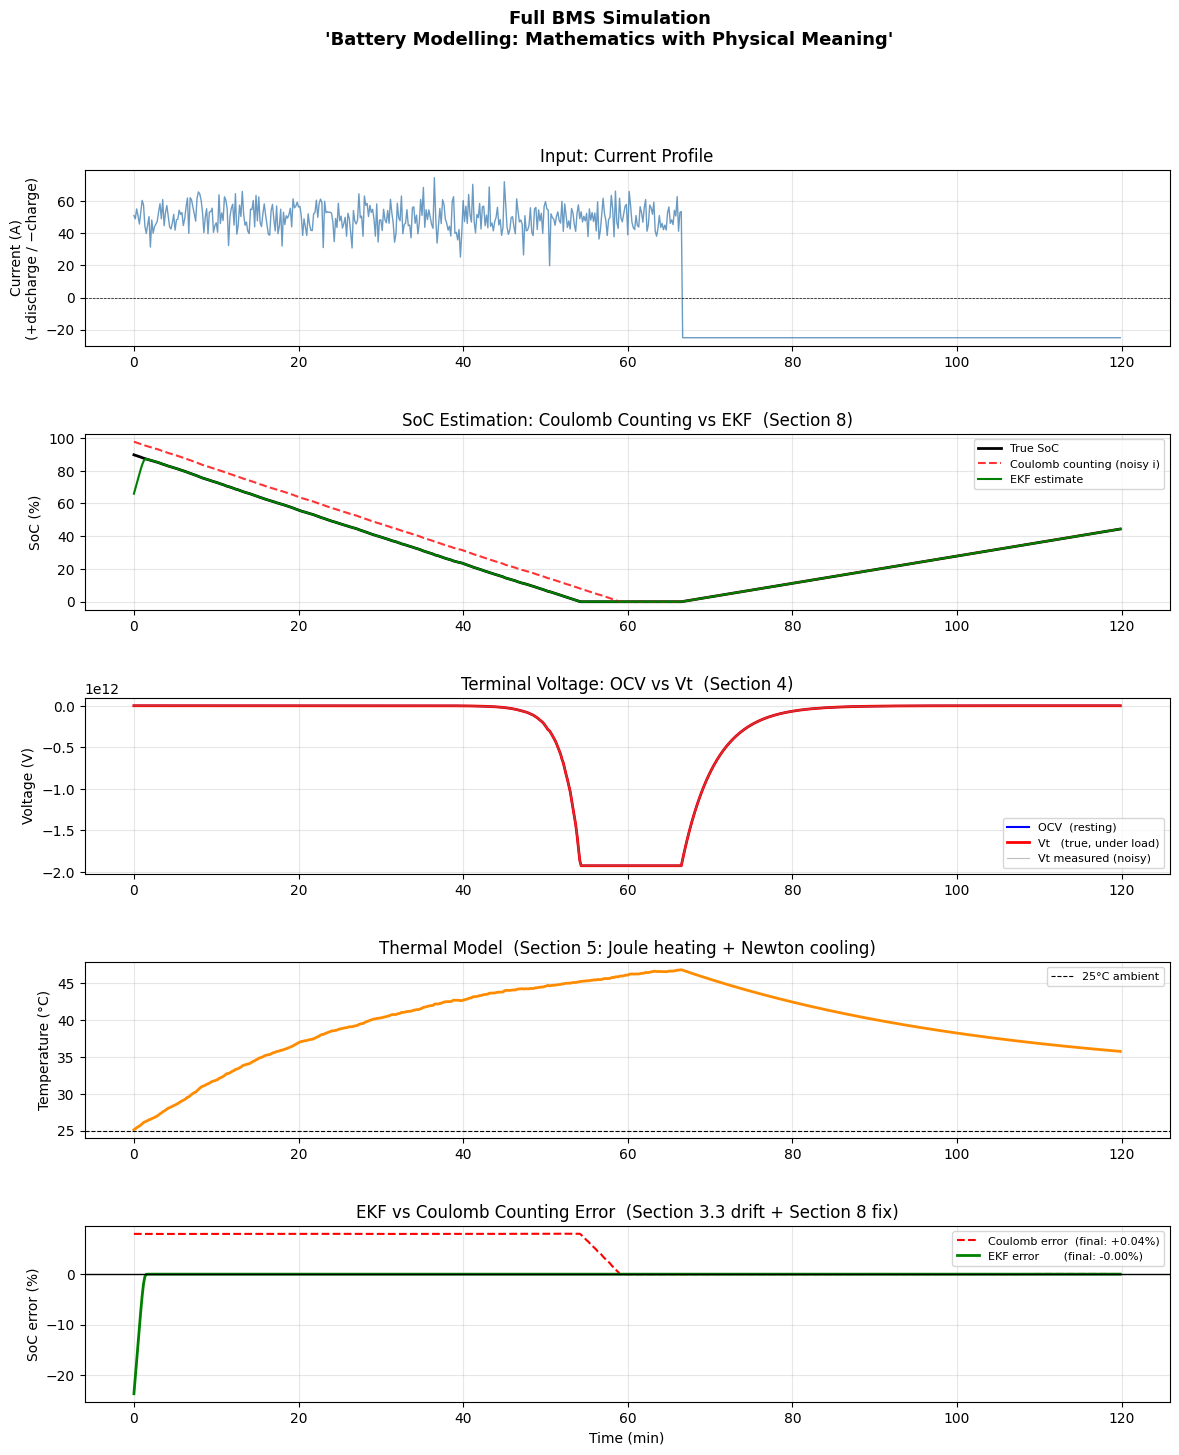


=== Simulation Summary ===
Duration          : 119.8 minutes
Final True SoC    : 44.41 %
Final EKF SoC     : 44.41 %  (error: -0.000%)
Final Coulomb SoC : 44.45 %  (error: +0.040%)
Max cell temp     : 46.8°C
SoH after sim     : 99.985%


In [17]:
# ============================================================
# CHAPTER 12 — Part D: Run the full simulation & plot results
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---- Set up cell and BMS ----
params = CellParameters(
    capacity_ah=50, chemistry="NMC",
    r0_ref=0.003, r1_ref=0.002, c1=5000,
    r2_ref=0.001, c2=100_000,
    ea_r0=6000, ea_r1=5000, ea_r2=4500,
)

cell = BatteryCell(params, soc_init=0.9, temperature_k=298.15)
bms  = BatteryManagementSystem(cell, dt_s=10, soc_init_error=0.08)

# ---- Current profile: WLTP-inspired drive cycle load  ----
# Phases: moderate load, high pulse, rest, charge
dt   = 10    # s
rng  = np.random.default_rng(0)

def make_current_profile(total_steps=720):
    """
    Simple two-phase profile:
      Phase 1 (0–400 steps): discharge at ~1C with random pulses
      Phase 2 (400–720 steps): charge at 0.5C CC
    """
    profile = []
    for k in range(total_steps):
        if k < 400:
            base = 50.0 + rng.normal(0, 8)   # ~1C ± noise
        else:
            base = -25.0                       # 0.5C charge
        profile.append(float(base))
    return profile

current_profile = make_current_profile(720)

# ---- Run simulation ----
print("Running BMS simulation (720 steps × 10s = 2 hours)...")
for I in current_profile:
    bms.step(I)

print(f"Done. Final state: SoC={cell.soc:.1%}  T={cell.thermal.T-273.15:.1f}°C  SoH={cell.fade.soh:.3f}")

# ---- Convert logs to arrays ----
L = bms.log
t_min = np.array(L["time"]) / 60   # seconds → minutes

# ============================================================
# Plots — five-panel figure covering the full paper
# ============================================================
fig = plt.figure(figsize=(14, 16))
fig.suptitle(
    "Full BMS Simulation\n"
    "'Battery Modelling: Mathematics with Physical Meaning'",
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(5, 1, hspace=0.50)

# Panel 1: Current profile
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_min, L["current"], color="steelblue", lw=1, alpha=0.8)
ax1.axhline(0, color='k', lw=0.5, ls='--')
ax1.set_ylabel("Current (A)\n(+discharge / −charge)")
ax1.set_title("Input: Current Profile")
ax1.grid(True, alpha=0.3)

# Panel 2: SoC comparison — True vs Coulomb vs EKF
ax2 = fig.add_subplot(gs[1])
ax2.plot(t_min, np.array(L["soc_true"])*100,     'k-',  lw=2,   label="True SoC")
ax2.plot(t_min, np.array(L["soc_coulomb"])*100,  'r--', lw=1.5, label="Coulomb counting (noisy i)", alpha=0.8)
ax2.plot(t_min, np.array(L["soc_ekf"])*100,      'g-',  lw=1.5, label="EKF estimate")
ax2.set_ylabel("SoC (%)")
ax2.set_title("SoC Estimation: Coulomb Counting vs EKF  (Section 8)")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Voltage — OCV vs terminal voltage vs measured
ax3 = fig.add_subplot(gs[2])
ax3.plot(t_min, L["ocv"],     'b-',  lw=1.5, label="OCV  (resting)")
ax3.plot(t_min, L["vt_true"], 'r-',  lw=2,   label="Vt   (true, under load)")
ax3.plot(t_min, L["vt_meas"], 'gray', lw=0.8, alpha=0.5, label="Vt measured (noisy)")
ax3.set_ylabel("Voltage (V)")
ax3.set_title("Terminal Voltage: OCV vs Vt  (Section 4)")
ax3.legend(loc="lower right", fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: Cell temperature (thermal model)
ax4 = fig.add_subplot(gs[3])
ax4.plot(t_min, L["temp_c"], color="darkorange", lw=2)
ax4.axhline(25, color='k', lw=0.8, ls='--', label="25°C ambient")
ax4.set_ylabel("Temperature (°C)")
ax4.set_title("Thermal Model  (Section 5: Joule heating + Newton cooling)")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Panel 5: EKF SoC error vs Coulomb error
ax5 = fig.add_subplot(gs[4])
err_cc  = (np.array(L["soc_coulomb"]) - np.array(L["soc_true"])) * 100
err_ekf = (np.array(L["soc_ekf"])    - np.array(L["soc_true"])) * 100
ax5.plot(t_min, err_cc,  'r--', lw=1.5, label=f"Coulomb error  (final: {err_cc[-1]:+.2f}%)")
ax5.plot(t_min, err_ekf, 'g-',  lw=2,   label=f"EKF error       (final: {err_ekf[-1]:+.2f}%)")
ax5.axhline(0, color='k', lw=1)
ax5.set_ylabel("SoC error (%)")
ax5.set_xlabel("Time (min)")
ax5.set_title("EKF vs Coulomb Counting Error  (Section 3.3 drift + Section 8 fix)")
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

plt.savefig("bms_simulation.png", dpi=120, bbox_inches='tight')
plt.show()

print("\n=== Simulation Summary ===")
print(f"Duration          : {t_min[-1]:.1f} minutes")
print(f"Final True SoC    : {L['soc_true'][-1]*100:.2f} %")
print(f"Final EKF SoC     : {L['soc_ekf'][-1]*100:.2f} %  (error: {err_ekf[-1]:+.3f}%)")
print(f"Final Coulomb SoC : {L['soc_coulomb'][-1]*100:.2f} %  (error: {err_cc[-1]:+.3f}%)")
print(f"Max cell temp     : {max(L['temp_c']):.1f}°C")
print(f"SoH after sim     : {L['soh'][-1]*100:.3f}%")

---
## Course Complete — What You Built

You started from `class BatteryCell: pass` and ended with a fully working **Battery Management System** running a real BMS loop. Here's the OOP–Physics map you traversed:

| Chapter | OOP Concept Mastered | Battery Physics Applied |
|---------|---------------------|-------------------------|
| 1 | Class definition, instantiation | A cell is an object |
| 2 | `__init__`, instance vs class attrs | Cell parameters: Q_nom, chemistry, T |
| 3 | Instance methods | OCV polynomial look-up, Coulomb counting |
| 4 | `@property` getter/setter | SoC bounded in [0,1], read-only OCV |
| 5 | `@classmethod`, `@staticmethod` | Alternative constructors, Arrhenius law |
| 6 | Dunder methods | Series battery pack, `+`, `len()`, iteration |
| 7 | Inheritance + `super()` | NMC / LFP / LTO with different OCV curves |
| 8 | Polymorphism | Chemistry-agnostic BMS loop |
| 9 | Abstract Base Classes | Enforced cell interface contract |
| 10 | Composition (has-a) | RCBranch → ECM → BatteryCell |
| 11 | `@dataclass`, type hints | ThermalModel, CapacityFadeModel |
| 12 | Full system design | Complete BMS: ECM + Thermal + Fade + EKF |

### Next Steps
- Swap in real measured OCV–SoC data from a CSV file (replace polynomial fit)
- Add a `BatteryPack` class that composes multiple `BatteryCell` objects in series/parallel
- Implement the Wang semi-empirical fade model using the `wang_fade()` method in `CapacityFadeModel`
- Add the unscented Kalman filter (UKF) for better accuracy near the flat LFP plateau